In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/Users/aimaankhan/Downloads/archive-2/UNSW_NB15_training-set.csv')

# 1. Handling Missing Values:
# For numerical columns:
numerical_columns = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'label']
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical columns:
categorical_columns = ['proto', 'service', 'state', 'attack_cat']
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 2. Removing Duplicates:
df.drop_duplicates(subset='id', inplace=True)

# 3. Data Type Consistency:
# Convert to integer
integer_columns = ['id', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'swin', 'stcpb', 'dtcpb', 'dwin', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'label']
for col in integer_columns:
    df[col] = df[col].astype(int)

# Convert to float
float_columns = ['dur', 'rate', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat']
for col in float_columns:
    df[col] = df[col].astype(float)

# 4. Standardizing Text Data:
for col in categorical_columns:
    df[col] = df[col].str.lower()

# 5. Handling Outliers (Initial Check):
# For the 'dur' column as an example:
Q1 = df['dur'].quantile(0.25)
Q3 = df['dur'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['dur'] = df['dur'].clip(lower_bound, upper_bound)
# ... repeat for other numerical columns if needed




In [14]:
df.head

<bound method NDFrame.head of           id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0          1  0.000011   udp       -   int      2      0     496       0   
1          2  0.000008   udp       -   int      2      0    1762       0   
2          3  0.000005   udp       -   int      2      0    1068       0   
3          4  0.000006   udp       -   int      2      0     900       0   
4          5  0.000010   udp       -   int      2      0    2126       0   
...      ...       ...   ...     ...   ...    ...    ...     ...     ...   
82327  82328  0.000005   udp       -   int      2      0     104       0   
82328  82329  1.106101   tcp       -   fin     20      8   18062     354   
82329  82330  0.000000   arp       -   int      1      0      46       0   
82330  82331  0.000000   arp       -   int      1      0      46       0   
82331  82332  0.000009   udp       -   int      2      0     104       0   

                rate  ...  ct_dst_sport_ltm  ct_dst_src_l

In [27]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Load the dataset
df = pd.read_csv('/Users/aimaankhan/Downloads/archive-2/UNSW_NB15_training-set.csv')

# One-hot encode the categorical columns using ColumnTransformer
categorical_columns = ['proto', 'service', 'state', 'attack_cat']
column_transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), categorical_columns)
    ],
    remainder='passthrough'
)

# Apply the transformation
data_array = column_transformer.fit_transform(df)

# Get the new one-hot encoded column names
new_columns = column_transformer.named_transformers_['encoder'].get_feature_names_out(categorical_columns)

# Get the remaining column names that were not transformed
remaining_columns = [col for col in df.columns if col not in categorical_columns]

# Combine the new one-hot encoded column names with the remaining column names
all_columns = list(new_columns) + remaining_columns

# Convert the sparse matrix to a dense array
dense_data_array = data_array.toarray()

# Convert the transformed data to a DataFrame
df_encoded = pd.DataFrame(dense_data_array, columns=all_columns)

# Define the input features X and the label Y
# Make sure 'label' is one of the columns in 'all_columns', otherwise replace 'label' with the correct target column name
X = df_encoded.drop('label', axis=1)
Y = df_encoded['label']


In [29]:
print(df_encoded.shape)
print(len(all_columns))
print(new_columns)

(82332, 198)
198
['proto_a/n' 'proto_aes-sp3-d' 'proto_any' 'proto_argus' 'proto_aris'
 'proto_arp' 'proto_ax.25' 'proto_bbn-rcc' 'proto_bna' 'proto_br-sat-mon'
 'proto_cbt' 'proto_cftp' 'proto_chaos' 'proto_compaq-peer' 'proto_cphb'
 'proto_cpnx' 'proto_crtp' 'proto_crudp' 'proto_dcn' 'proto_ddp'
 'proto_ddx' 'proto_dgp' 'proto_egp' 'proto_eigrp' 'proto_emcon'
 'proto_encap' 'proto_etherip' 'proto_fc' 'proto_fire' 'proto_ggp'
 'proto_gmtp' 'proto_gre' 'proto_hmp' 'proto_i-nlsp' 'proto_iatp'
 'proto_ib' 'proto_idpr' 'proto_idpr-cmtp' 'proto_idrp' 'proto_ifmp'
 'proto_igmp' 'proto_igp' 'proto_il' 'proto_ip' 'proto_ipcomp'
 'proto_ipcv' 'proto_ipip' 'proto_iplt' 'proto_ipnip' 'proto_ippc'
 'proto_ipv6' 'proto_ipv6-frag' 'proto_ipv6-no' 'proto_ipv6-opts'
 'proto_ipv6-route' 'proto_ipx-n-ip' 'proto_irtp' 'proto_isis'
 'proto_iso-ip' 'proto_iso-tp4' 'proto_kryptolan' 'proto_l2tp'
 'proto_larp' 'proto_leaf-1' 'proto_leaf-2' 'proto_merit-inp'
 'proto_mfe-nsp' 'proto_mhrp' 'proto_micp' 'proto_

In [22]:

# Assuming the last column is the label and the rest are features
# Adjust the indices as per your dataset
X = df_encoded.iloc[:, :-2]  # Select all columns except the last one as features
Y = df_encoded.iloc[:, -1]   # Select the last column as label

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Assuming you have already preprocessed the training data and have X and Y
# Load the new dataset for testing
df_test = pd.read_csv('/Users/aimaankhan/Desktop/Internship/preprocessed_testing_data.csv')


# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)

# Train the model on the training data
rf_classifier.fit(X, Y)  # X and Y are your preprocessed training features and labels

# Make predictions on the test data
Y_pred = rf_classifier.predict(X_test)

# Evaluate the model on the test data
print("Classification Report:")
print(classification_report(Y_test, Y_pred))
print("Accuracy Score:", accuracy_score(Y_test, Y_pred))



Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7418
         1.0       1.00      1.00      1.00      9049

    accuracy                           1.00     16467
   macro avg       1.00      1.00      1.00     16467
weighted avg       1.00      1.00      1.00     16467

Accuracy Score: 1.0


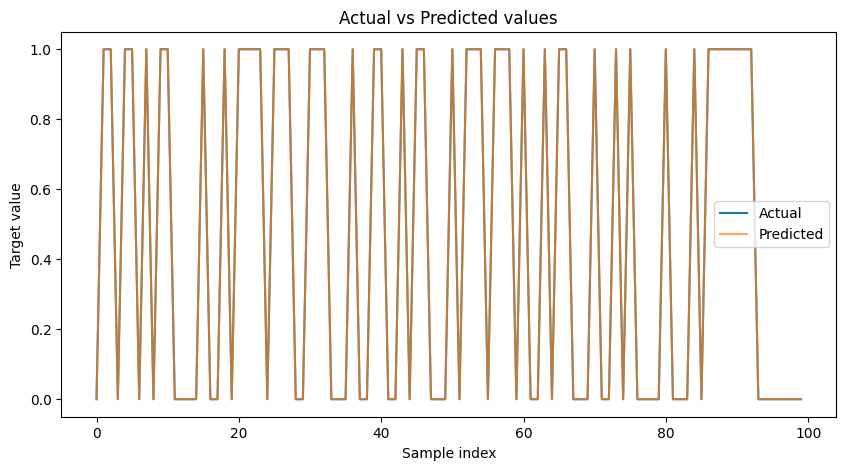

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(Y_test.values[:100], label='Actual')
plt.plot(Y_pred[:100], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted values')
plt.xlabel('Sample index')
plt.ylabel('Target value')
plt.legend()
plt.show()

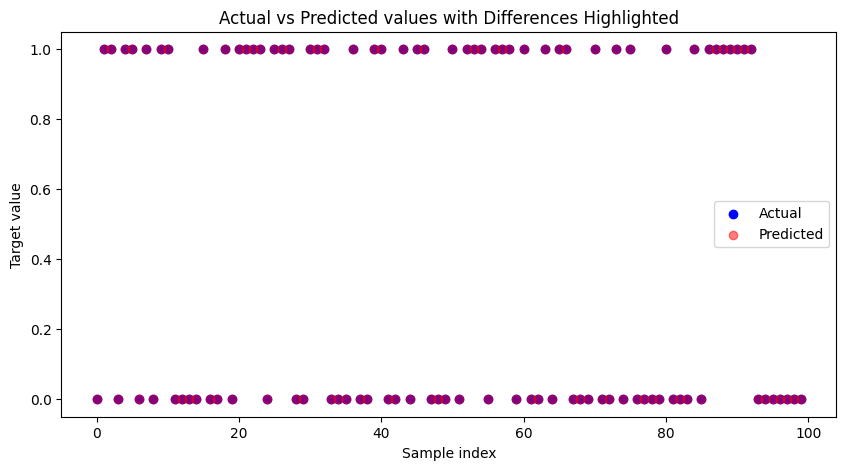

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

# Plot all actual values
plt.scatter(range(len(Y_test[:100])), Y_test.values[:100], color='blue', label='Actual')

# Plot predicted values
plt.scatter(range(len(Y_pred[:100])), Y_pred[:100], color='red', alpha=0.5, label='Predicted')

# Highlight the differences
for i in range(len(Y_test[:100])):
    if Y_test.values[i] != Y_pred[i]:
        plt.scatter(i, Y_test.values[i], color='orange')

plt.title('Actual vs Predicted values with Differences Highlighted')
plt.xlabel('Sample index')
plt.ylabel('Target value')
plt.legend()
plt.show()
